In [4]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_style("whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import os

if not os.path.exists("charts"):
    os.makedirs("charts")

In [6]:
#load dataset
df = pd.read_excel("Downloads/Coffee Shop Sales.xlsx")
print(df.head())

   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg 

In [7]:
#Basic dataset transformation
print("Shape :", df.shape)
df.info()
df.describe()

Shape : (149116, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [8]:
#Missing values check 
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [9]:
#Create folders for Charts
import os
if not os.path.exists("charts"):
    os.makedirs("charts")
print("Charts Folder Created")

Charts Folder Created


In [10]:
#Coffee theme colours 
sns.set_style("white")

plt.rcParams['figure.facecolor'] = '#F5EFE6'
plt.rcParams['axes.facecolor'] = '#FAF6F0'
plt.rcParams['axes.edgecolor'] = '#8B6B4A'
plt.rcParams['axes.labelcolor'] = '#4E342E'
plt.rcParams['xtick.color'] = '#4E342E'
plt.rcParams['ytick.color'] = '#4E342E'
plt.rcParams['text.color'] = '#3E2723'
plt.rcParams['font.size'] = 12

In [15]:
# Create Month Column
df['Month'] = df['transaction_date'].dt.month_name()

# Monthly Sales
monthly_sales = (df.groupby('Month')['transaction_qty'].sum().reindex([
        'January','February','March',
        'April','May','June',
        'July','August','September',
        'October','November','December']).dropna())

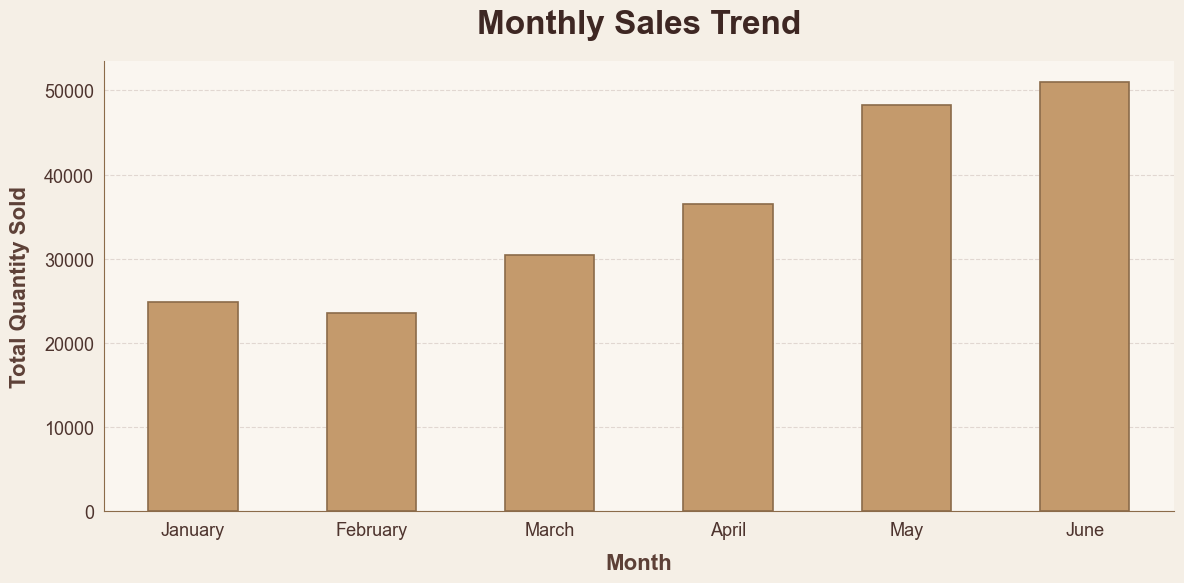

In [14]:
#Monthly sales trend
plt.figure(figsize=(12,6), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
monthly_sales.plot(kind='bar',color='#C49A6C',edgecolor='#8B6B4A',linewidth=1.2)
plt.title("Monthly Sales Trend",fontsize=24,fontweight='bold',color='#3E2723',pad=20)
plt.xlabel("Month",fontsize=16,fontweight='bold',color='#5D4037',labelpad=10)
plt.ylabel("Total Quantity Sold",fontsize=16,fontweight='bold',color='#5D4037',labelpad=10)
plt.xticks(fontsize=13,color='#4E342E',rotation=0)
plt.yticks(fontsize=13,color='#4E342E')
plt.grid(axis='y',linestyle='--',alpha=0.4,color='#BCAAA4')

# Top and right border remove
sns.despine()
plt.tight_layout()
plt.savefig("charts/01_monthly_sales.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

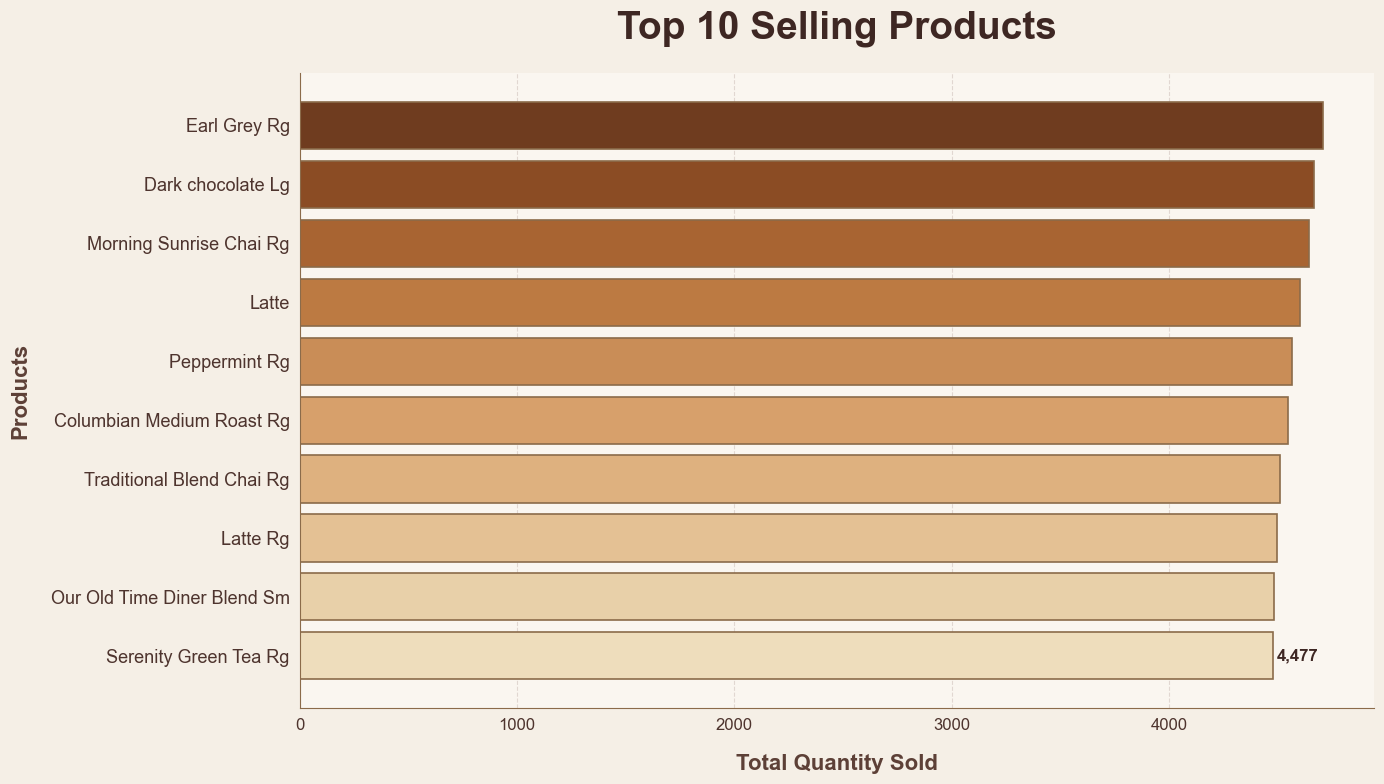

In [16]:
#Top 10 Products
top_products = (df.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(14,8), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')

# Coffee Gradient Palette
colors = [
    '#6F3C1F','#8B4C24','#A86432','#BC7A42','#C98D57','#D7A06B','#DEB17F','#E4C194','#E8D0A9','#EEDDBC']

bars = plt.barh(top_products.index,top_products.values,color=colors,edgecolor='#8B6B4A',linewidth=1.2)
plt.gca().invert_yaxis()

# Value Labels
for bar in bars:
    width = bar.get_width()
plt.text(width + 20,bar.get_y() + bar.get_height()/2,f'{int(width):,}',va='center',fontsize=12,color='#3E2723',fontweight='bold')
plt.title('Top 10 Selling Products',fontsize=28,fontweight='bold',color='#3E2723',pad=25)
plt.xlabel('Total Quantity Sold',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.ylabel('Products',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.xticks(fontsize=12,color='#4E342E')
plt.yticks(fontsize=13,color='#4E342E')
plt.grid(axis='x', linestyle='--',alpha=0.4,color='#BCAAA4')

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("charts/02_top_products.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

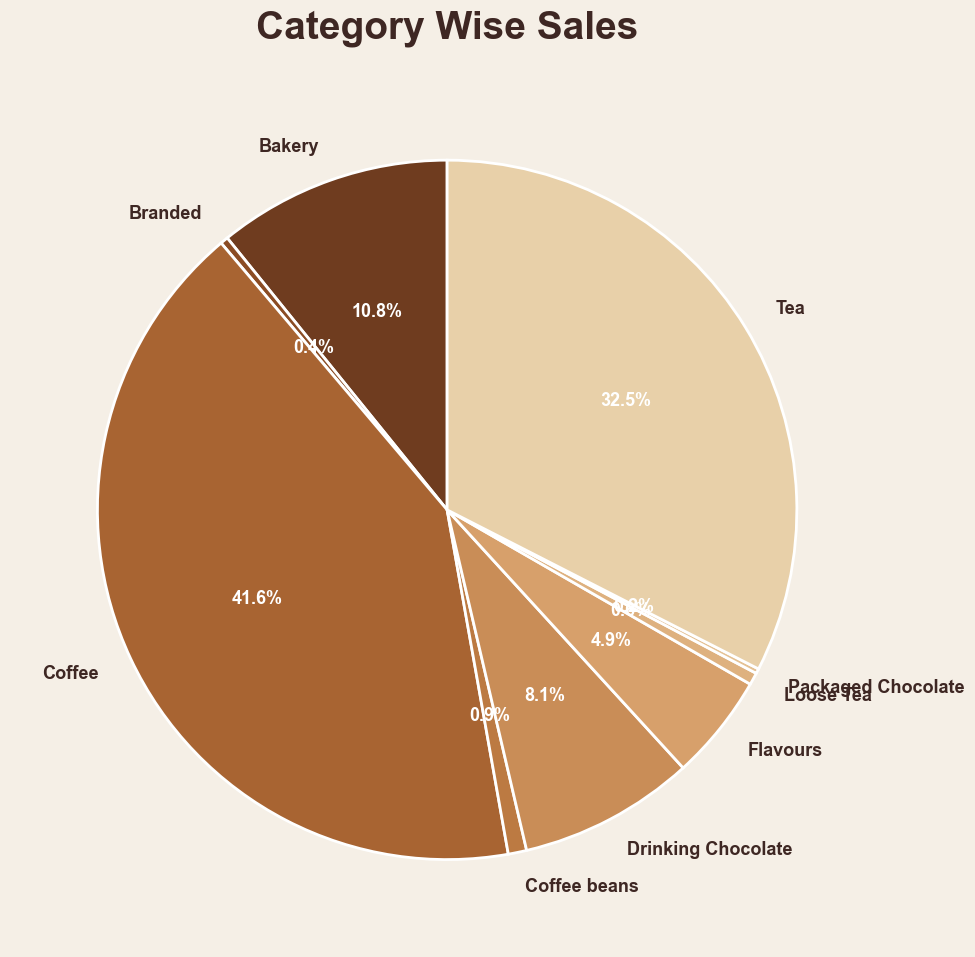

In [17]:
#Category wise sales
# Category Wise Sales
category_sales = (df.groupby('product_category')['transaction_qty'].sum())
plt.figure(figsize=(10,10), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
colors = ['#6F3C1F','#8B4C24','#A86432','#BC7A42','#C98D57','#D7A06B','#DEB17F','#E4C194','#E8D0A9','#EEDDBC']
wedges, texts, autotexts = plt.pie(category_sales,labels=category_sales.index,colors=colors[:len(category_sales)],autopct='%1.1f%%',startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},textprops={'fontsize':13,'color':'#3E2723','fontweight':'bold'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
plt.title('Category Wise Sales',fontsize=28,fontweight='bold',color='#3E2723',pad=25)
plt.tight_layout()
plt.savefig("charts/03_category_sales.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

In [18]:
df['Hour'] = df['transaction_time'].astype(str).str[:2].astype(int)

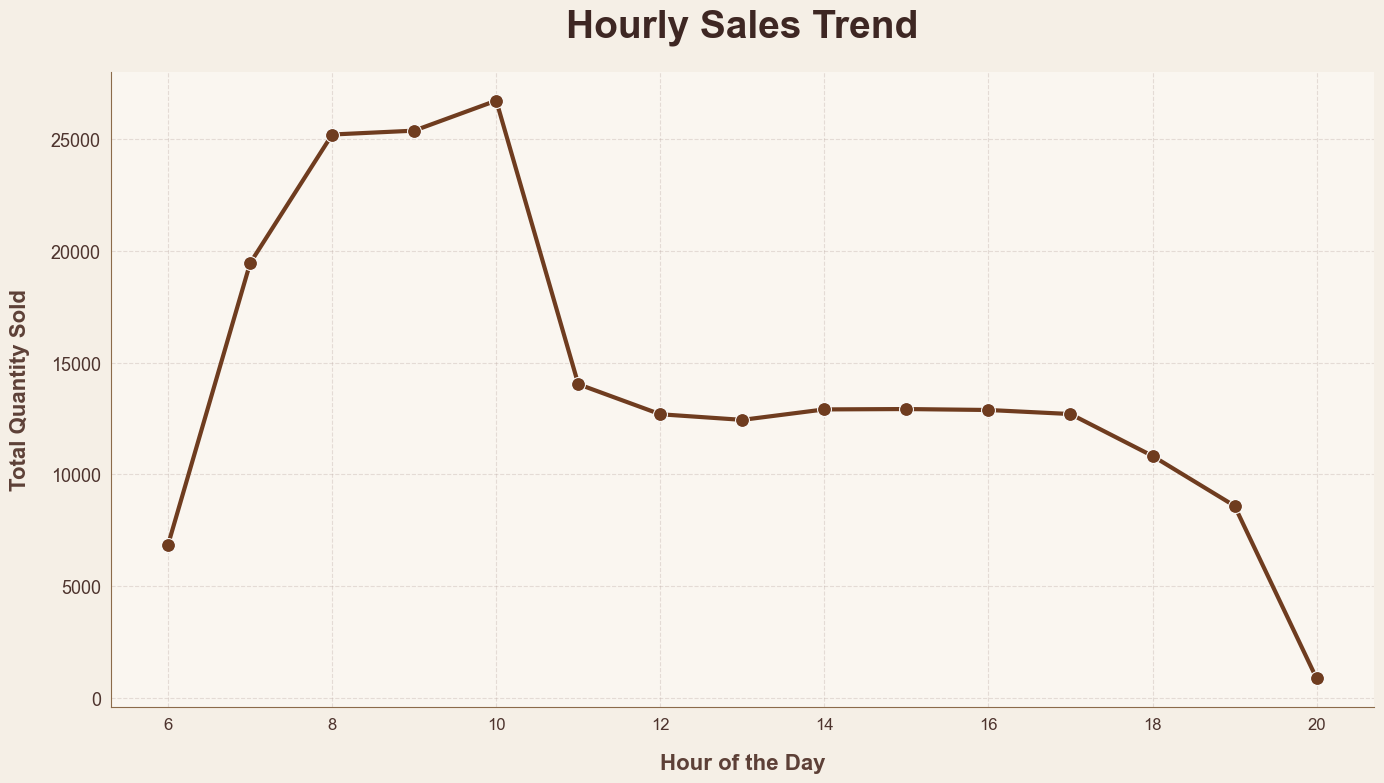

In [19]:
# Hourly Sales Trend
df['Hour'] = df['transaction_time'].apply(lambda x: x.hour)
hourly_sales = (df.groupby('Hour')['transaction_qty'].sum())
plt.figure(figsize=(14,8), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')

sns.lineplot(x=hourly_sales.index,y=hourly_sales.values,marker='o',linewidth=3,markersize=10,color='#6F3C1F')
plt.title('Hourly Sales Trend', fontsize=28, fontweight='bold', color='#3E2723', pad=25)
plt.xlabel('Hour of the Day', fontsize=16, fontweight='bold', color='#5D4037', labelpad=15)
plt.ylabel('Total Quantity Sold', fontsize=16, fontweight='bold', color='#5D4037', labelpad=15)
plt.xticks(fontsize=12, color='#4E342E')
plt.yticks(fontsize=13, color='#4E342E')
plt.grid(axis='both', linestyle='--', alpha=0.35, color='#BCAAA4')
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("charts/04_hourly_sales.png", dpi=300, bbox_inches='tight', facecolor='#F5EFE6')
plt.show()

In [20]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail',
 'Month',
 'Hour']

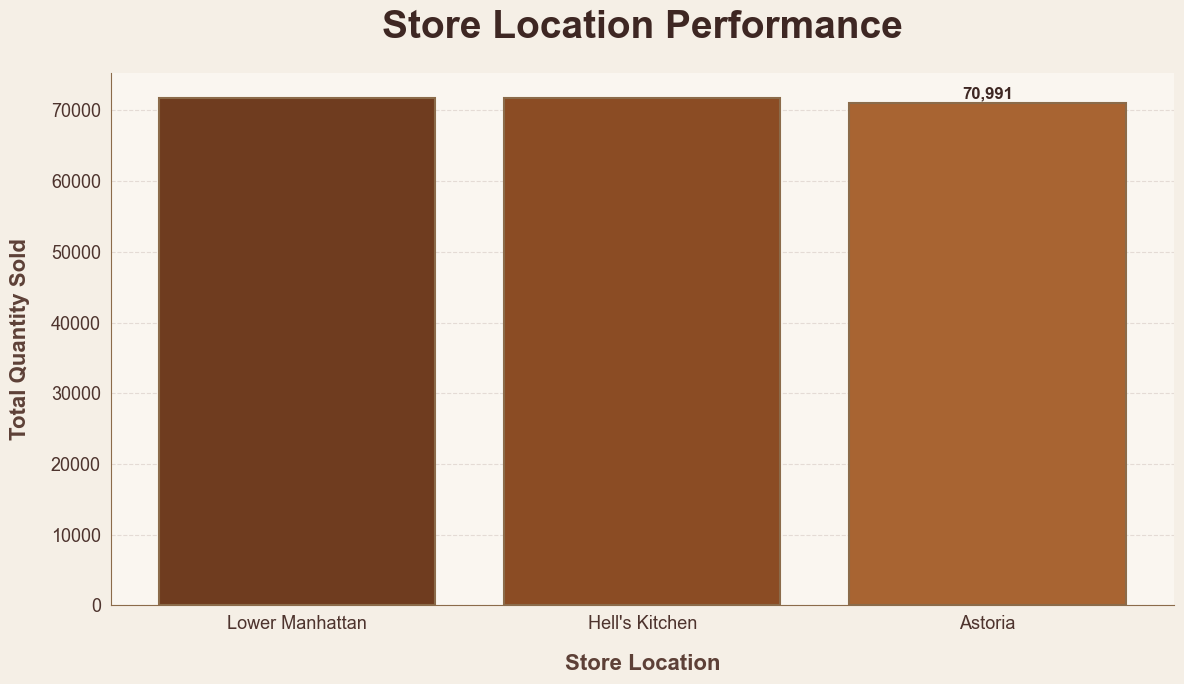

In [21]:
# Store Location Performance
location_sales = (df.groupby('store_location')['transaction_qty'].sum().sort_values(ascending=False))
plt.figure(figsize=(12,7), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
colors = ['#6F3C1F','#8B4C24','#A86432','#BC7A42','#C98D57']
bars = plt.bar(location_sales.index,location_sales.values,color=colors[:len(location_sales)],edgecolor='#8B6B4A',linewidth=1.5)
for bar in bars:
    height = bar.get_height()
plt.text(bar.get_x() + bar.get_width()/2,height + (location_sales.max()*0.01),f'{int(height):,}',ha='center',fontsize=12,color='#3E2723',fontweight='bold')
plt.title('Store Location Performance', fontsize=28, fontweight='bold', color='#3E2723', pad=25)
plt.xlabel('Store Location', fontsize=16, fontweight='bold', color='#5D4037', labelpad=15)
plt.ylabel('Total Quantity Sold', fontsize=16, fontweight='bold', color='#5D4037', labelpad=15)
plt.xticks(fontsize=13, color='#4E342E')
plt.yticks(fontsize=13, color='#4E342E')
plt.grid(axis='y', linestyle='--', alpha=0.35, color='#BCAAA4')
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("charts/05_store_location.png", dpi=300, bbox_inches='tight', facecolor='#F5EFE6')
plt.show()

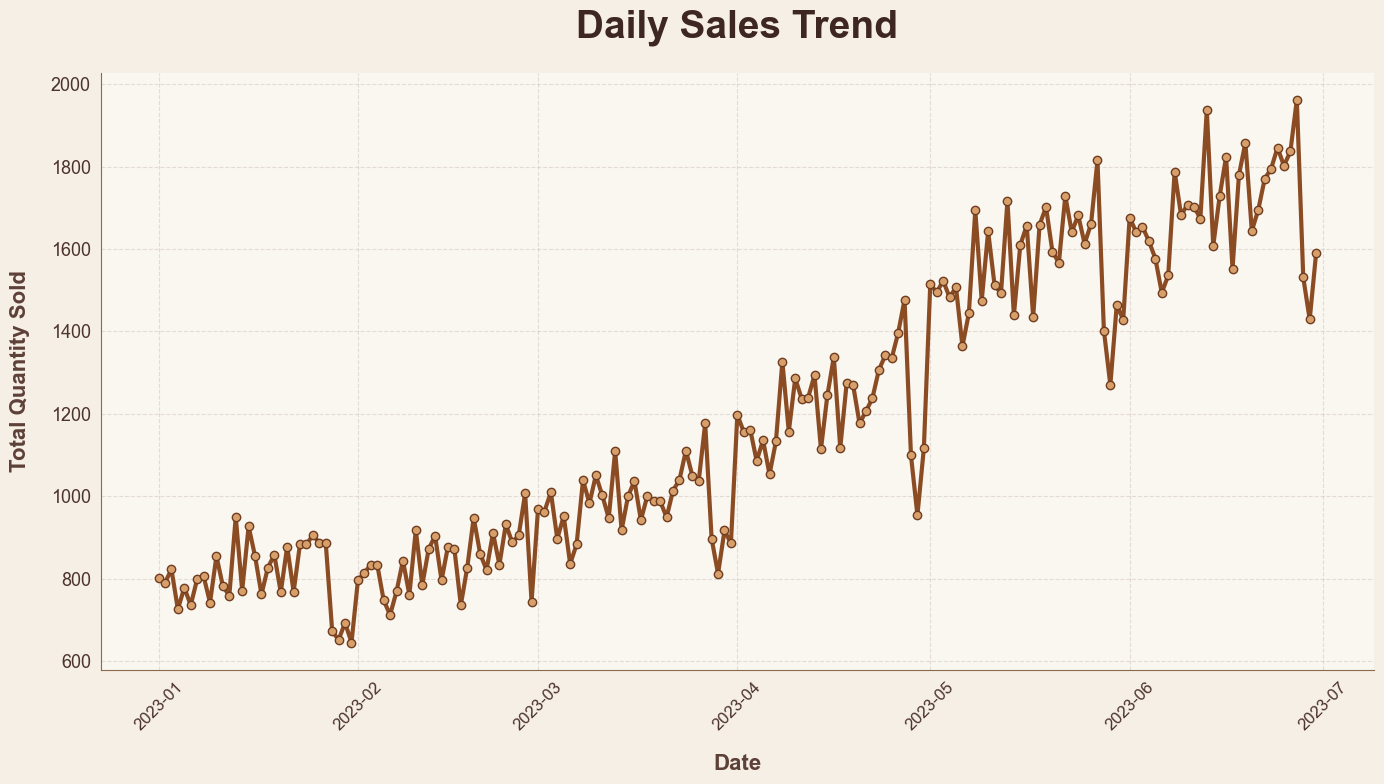

In [22]:
# Daily Sales Trend
daily_sales = (df.groupby('transaction_date')['transaction_qty'].sum())
plt.figure(figsize=(14,8), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
plt.plot(daily_sales.index,daily_sales.values,color='#8B4C24',linewidth=3,marker='o',markersize=6,markerfacecolor='#D7A06B',markeredgecolor='#6F3C1F')
plt.title('Daily Sales Trend',fontsize=28,fontweight='bold',color='#3E2723',pad=25)
plt.xlabel('Date',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.ylabel('Total Quantity Sold',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.xticks(fontsize=12,color='#4E342E',rotation=45)
plt.yticks(fontsize=13,color='#4E342E')
plt.grid(axis='both',linestyle='--',alpha=0.35,color='#BCAAA4')
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("charts/06_daily_trend.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

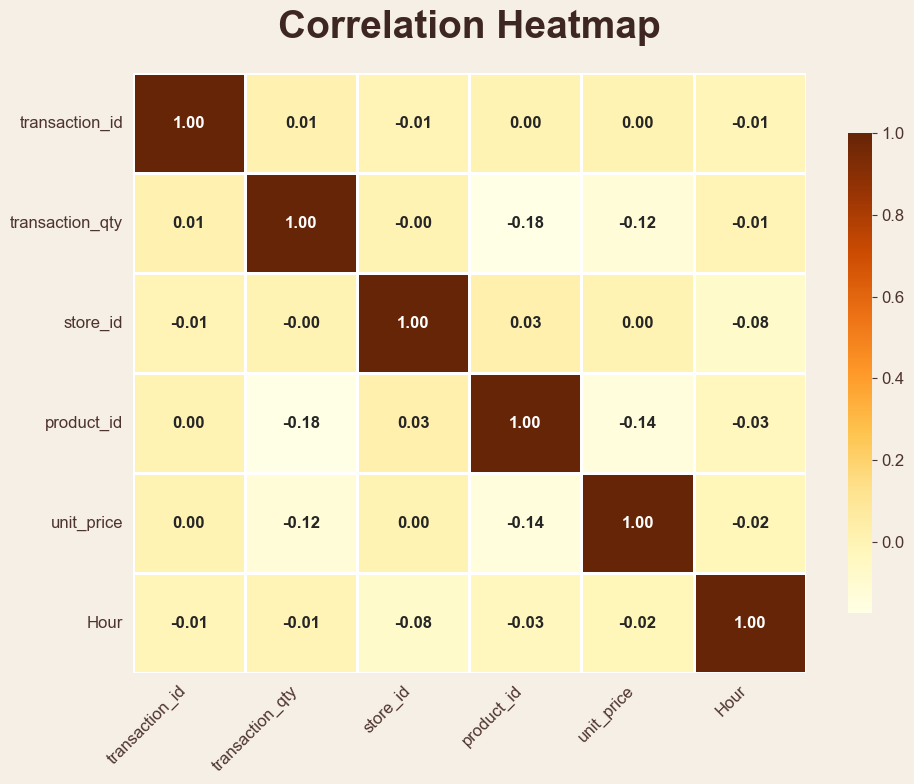

In [23]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
sns.heatmap(numeric_df.corr(),annot=True,fmt='.2f',cmap='YlOrBr',linewidths=1,linecolor='white',annot_kws={'size':12,'weight':'bold'},cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap',fontsize=28,fontweight='bold',color='#3E2723',pad=25)
plt.xticks(fontsize=12,color='#4E342E',rotation=45,ha='right')
plt.yticks(fontsize=12,color='#4E342E', rotation=0)
plt.tight_layout()
plt.savefig("charts/07_correlation_heatmap.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

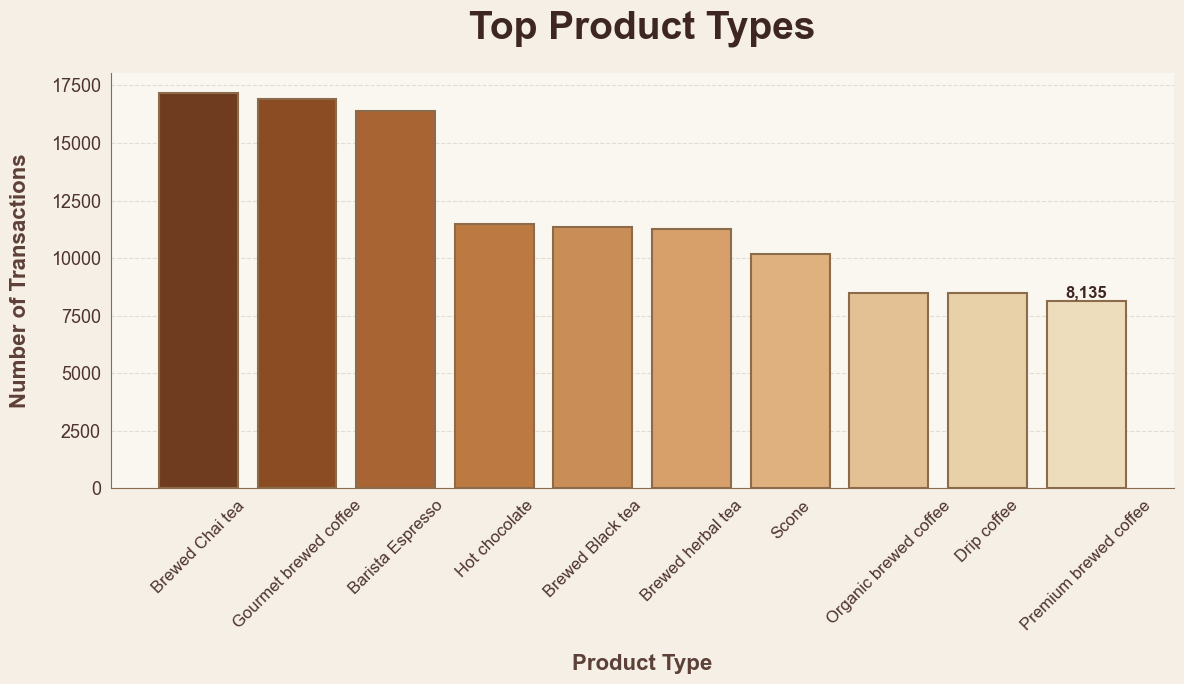

In [24]:
#Product type analysis
# Product Type Analysis
product_type = (df['product_type'].value_counts().head(10))
plt.figure(figsize=(12,7), facecolor='#F5EFE6')
ax = plt.gca()
ax.set_facecolor('#FAF6F0')
colors = ['#6F3C1F','#8B4C24','#A86432','#BC7A42','#C98D57','#D7A06B','#DEB17F','#E4C194','#E8D0A9','#EEDDBC']
bars = plt.bar(product_type.index,product_type.values,color=colors[:len(product_type)],edgecolor='#8B6B4A',linewidth=1.5)
for bar in bars:
    height = bar.get_height()
plt.text(bar.get_x()+bar.get_width()/2,height+(product_type.max()*0.01),f'{int(height):,}',ha='center',fontsize=12,color='#3E2723',fontweight='bold')
plt.title('Top Product Types',fontsize=28,fontweight='bold',color='#3E2723',pad=25)
plt.xlabel('Product Type',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.ylabel('Number of Transactions',fontsize=16,fontweight='bold',color='#5D4037',labelpad=15)
plt.xticks(rotation=45,fontsize=12,color='#4E342E')
plt.yticks(fontsize=13,color='#4E342E')
plt.grid(axis='y',linestyle='--',alpha=0.35,color='#BCAAA4')
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("charts/08_product_type.png",dpi=300,bbox_inches='tight',facecolor='#F5EFE6')
plt.show()

In [26]:
print("Dataset Rows :", df.shape[0])
print("Dataset Columns :", df.shape[1])

print("\nAnalysis Completed Successfully")
print("All Charts Saved In Charts Folder")

Dataset Rows : 149116
Dataset Columns : 13

Analysis Completed Successfully
All Charts Saved In Charts Folder
